# House pricing

Este notebook corresponde a una práctica de regresión de Kaggle vinculada a los precios de propiedades en función de sus características.

## Análisis y preprocesamiento

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [177]:
data = pd.read_csv("./train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [178]:
data.shape

(1460, 81)

In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [180]:
data.isna().sum().values

array([   0,    0,    0,  259,    0,    0, 1369,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,  872,    8,    0,    0,    0,   37,   37,   38,
         37,    0,   38,    0,    0,    0,    0,    0,    0,    1,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,  690,   81,   81,   81,    0,    0,   81,   81,    0,
          0,    0,    0,    0,    0,    0, 1453, 1179, 1406,    0,    0,
          0,    0,    0,    0])

In [181]:
# columnas con valores faltantes
columns_with_na = data.columns[data.isnull().any()].tolist()
columns_with_na

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [182]:
data[columns_with_na].dtypes

,0
LotFrontage,float64
Alley,object
MasVnrType,object
MasVnrArea,float64
BsmtQual,object
BsmtCond,object
BsmtExposure,object
BsmtFinType1,object
BsmtFinType2,object
Electrical,object


Tenemos datos faltantes en columnas tanto categóricas como numéricas.

Podemos elegir una estrategia de imputación diferente según el tipo de dato de cada columna.

Probaremos la imputación por medio de SimpleImputer para columnas categóricas, y por medio de KNNImputer para las numéricas.

In [183]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [184]:
na_num_cols = data[columns_with_na].select_dtypes(include=['number', 'float64', 'int64']).columns.to_list()
na_cat_cols = data[columns_with_na].select_dtypes(include=['object']).columns.to_list()
cat_columns = data.select_dtypes(include=['object']).columns.to_list()

In [185]:
data_scaled = data.copy()
scaler = MinMaxScaler()
data_scaled[na_num_cols] = scaler.fit_transform(data_scaled[na_num_cols])
data_scaled.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [186]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", KNNImputer(n_neighbors=5), na_num_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), na_cat_cols)
    ],
    remainder="passthrough",  # Mantiene las demás columnas sin cambios
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [187]:
transformed_data = preprocessor.fit_transform(data_scaled)
transformed_data = transformed_data[data.columns]
transformed_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [188]:
# retornamos al rango original
transformed_data[na_num_cols] = scaler.inverse_transform(transformed_data[na_num_cols])
transformed_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [189]:
transformed_data.isna().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Ahora debemos hacer un tratamiento de las columnas categóricas. Dado que el uso de LabelEncoder puede hacernos incurrir en errores por aplicar un número de orden a als categoráis de las columnas que puede no tener relación alguna con el contexto actual, usaremos OneHotEncoder y luego se aplicará PCA para reducir la consecuente dimensionalidad.

In [191]:
final_data = pd.get_dummies(transformed_data, columns=cat_columns, drop_first=True)
final_data.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [193]:
final_data.shape

(1460, 246)

In [192]:
corr_matrix = final_data.corr()
corr_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,1.000000,0.011156,-0.005559,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.048916,-0.005024,...,-0.058765,-0.020738,-0.018998,0.038920,0.026133,-0.034852,-0.009018,0.004865,0.015881,-0.020738
MSSubClass,0.011156,1.000000,-0.353603,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.021860,-0.069836,...,-0.001244,0.014005,-0.045156,-0.014555,0.026359,0.016241,0.030002,0.000983,0.024359,-0.051068
LotFrontage,-0.005559,-0.353603,1.000000,0.282002,0.235392,-0.048418,0.107884,0.080693,0.201237,0.200551,...,0.008624,-0.046901,0.139781,-0.020313,-0.093903,-0.033004,-0.020998,0.011365,-0.080935,0.138277
LotArea,-0.033226,-0.139781,0.282002,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103750,0.214103,...,0.001076,-0.015040,0.020039,-0.005722,-0.002292,-0.013208,0.008966,-0.010781,0.005711,0.022635
OverallQual,-0.028365,0.032628,0.235392,0.105806,1.000000,-0.091932,0.572323,0.550684,0.412557,0.239666,...,0.004269,-0.021172,0.327412,-0.057962,-0.225013,-0.041677,-0.044950,-0.025515,-0.143282,0.323295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleCondition_AdjLand,-0.034852,0.016241,-0.033004,-0.013208,-0.041677,-0.038888,-0.045601,-0.040294,-0.011977,-0.014874,...,-0.003073,-0.003073,-0.015827,-0.002378,0.020457,1.000000,-0.004772,-0.006177,-0.112080,-0.016038
SaleCondition_Alloca,-0.009018,0.030002,-0.020998,0.008966,-0.044950,-0.033444,-0.010104,-0.020727,-0.012833,0.021369,...,-0.005337,-0.005337,-0.027489,-0.004131,0.035530,-0.004772,1.000000,-0.010729,-0.194663,-0.027856
SaleCondition_Family,0.004865,0.000983,0.011365,-0.010781,-0.025515,-0.023873,-0.035785,-0.048056,-0.009971,0.000765,...,-0.006909,-0.006909,-0.035587,-0.005348,0.028599,-0.006177,-0.010729,1.000000,-0.252006,-0.036062
SaleCondition_Normal,0.015881,0.024359,-0.080935,0.005711,-0.143282,0.161642,-0.158427,-0.120577,-0.085720,-0.019560,...,-0.003139,0.027414,-0.645698,-0.097031,0.634322,-0.112080,-0.194663,-0.252006,1.000000,-0.654323


Como tenemos muchas columnas, nos interesaría solo preservar aquellas que poseen una correlación media-alta con la característica objetivo (SalePrice)

In [194]:
target_corr = corr_matrix['SalePrice'].abs()  # Obtener la correlación absoluta con la columna objetivo
selected_cols = target_corr[target_corr > 0.40].index
selected_cols

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF',
       '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice',
       'Neighborhood_NridgHt', 'ExterQual_Gd', 'ExterQual_TA',
       'Foundation_PConc', 'BsmtQual_TA', 'BsmtFinType1_GLQ', 'KitchenQual_TA',
       'GarageFinish_Unf'],
      dtype='object')

In [195]:
filtered_data = final_data[selected_cols]
filtered_data.head()

,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,...,GarageArea,SalePrice,Neighborhood_NridgHt,ExterQual_Gd,ExterQual_TA,Foundation_PConc,BsmtQual_TA,BsmtFinType1_GLQ,KitchenQual_TA,GarageFinish_Unf
0,7,2003,2003,196.0,856,856,1710,2,8,0,...,548,208500,False,True,False,True,False,True,False,False
1,6,1976,1976,0.0,1262,1262,1262,2,6,1,...,460,181500,False,False,True,False,False,False,True,False
2,7,2001,2002,162.0,920,920,1786,2,6,1,...,608,223500,False,True,False,True,False,True,False,False
3,7,1915,1970,0.0,756,961,1717,1,7,1,...,642,140000,False,False,True,False,True,False,False,True
4,8,2000,2000,350.0,1145,1145,2198,2,9,1,...,836,250000,False,True,False,True,False,True,False,False


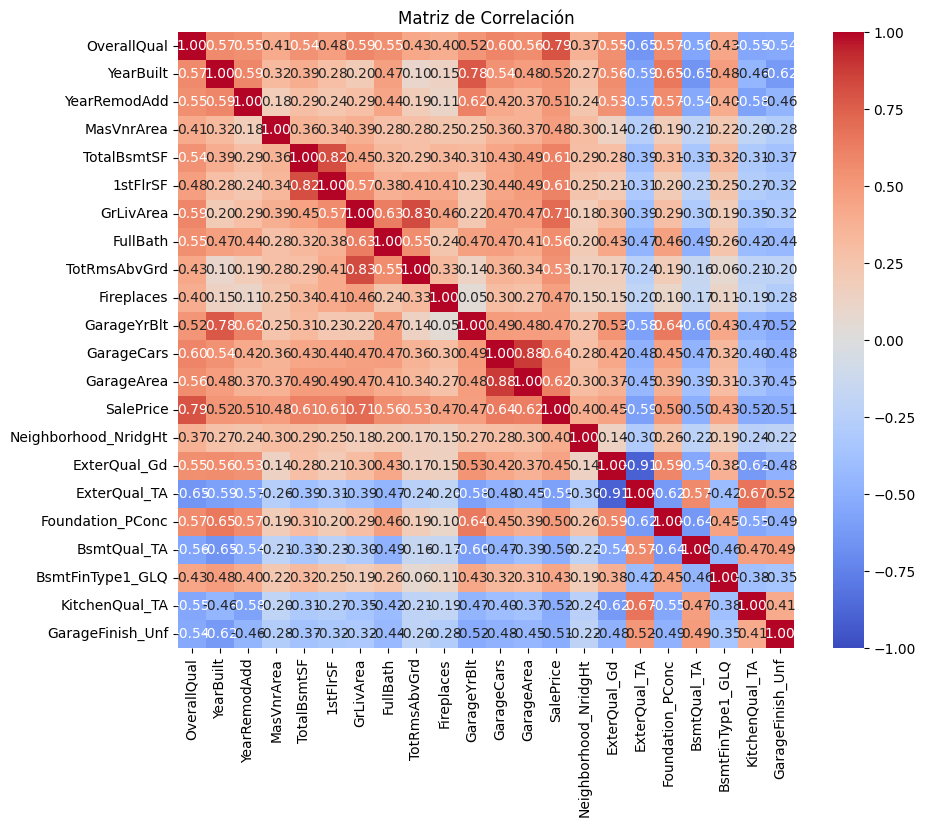

In [196]:
corr_matrix = filtered_data.corr()

plt.figure(figsize=(10, 8))  # Ajusta el tamaño de la figura si es necesario
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)

# Mostrar el gráfico
plt.title('Matriz de Correlación')
plt.show()

### Alternativa con PCA para reducir dimensionalidad

In [198]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [197]:
X = final_data.drop(columns=["SalePrice"], axis=1)
y = final_data["SalePrice"]

## Entrenamiento del modelo